In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [2]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.shape

(253680, 22)

In [4]:
df.tail(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253670,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
253671,0.0,1.0,1.0,1.0,23.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,4.0,0.0,5.0,0.0,1.0,8.0,3.0,2.0
253672,0.0,1.0,0.0,1.0,30.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,2.0,1.0
253673,0.0,1.0,0.0,1.0,42.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,14.0,4.0,0.0,1.0,3.0,6.0,8.0
253674,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,6.0,5.0
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [5]:
df.describe(include="all")

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
for column in df.columns:
    num_unique_values = df[column].nunique()
    print(f"{column}: {num_unique_values}")

Diabetes_012: 3
HighBP: 2
HighChol: 2
CholCheck: 2
BMI: 84
Smoker: 2
Stroke: 2
HeartDiseaseorAttack: 2
PhysActivity: 2
Fruits: 2
Veggies: 2
HvyAlcoholConsump: 2
AnyHealthcare: 2
NoDocbcCost: 2
GenHlth: 5
MentHlth: 31
PhysHlth: 31
DiffWalk: 2
Sex: 2
Age: 13
Education: 6
Income: 8


In [8]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 23899


In [10]:
df = df.drop_duplicates()
df.shape

(229781, 22)

In [11]:
target = "Diabetes_012"

features = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
]

X = df[features].copy()
y = df[target].copy().astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (229781, 21)
y shape: (229781,)


In [ ]:
print(y.value_counts().sort_index())
print("\nClass percentages:\n")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Diabetes_012
0    190055
1      4629
2     35097
Name: count, dtype: int64

Class percentages:

Diabetes_012
0    82.71
1     2.01
2    15.27
Name: proportion, dtype: float64


In [ ]:
X = X.fillna(X.median(numeric_only=True))
X.isnull().sum().sum()

np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (183824, 21)
X_test shape: (45957, 21)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (183824, 21)
Scaled testing shape: (45957, 21)


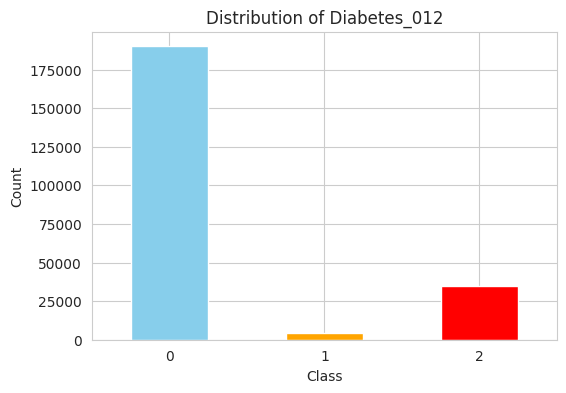

In [ ]:
plt.figure(figsize=(6,4))
y.value_counts().sort_index().plot(kind="bar", color=["skyblue", "orange", "red"])
plt.title("Distribution of Diabetes_012")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

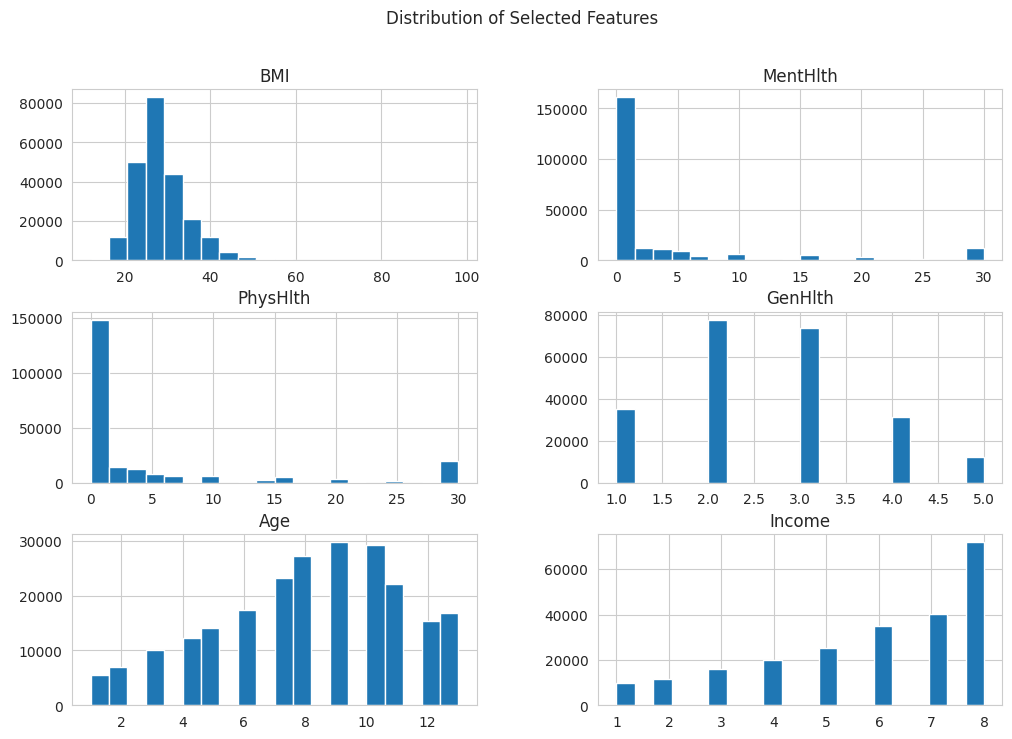

In [ ]:
X[['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Income']].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Selected Features")
plt.show()

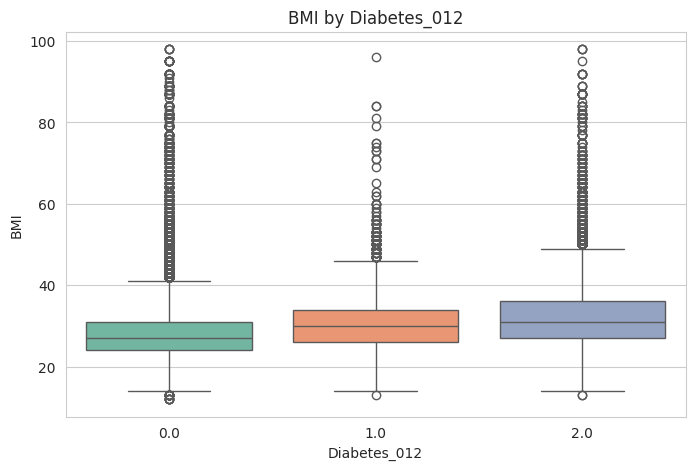

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df[target], y=df["BMI"], palette="Set2")
plt.title("BMI by Diabetes_012")
plt.xlabel("Diabetes_012")
plt.ylabel("BMI")
plt.show()

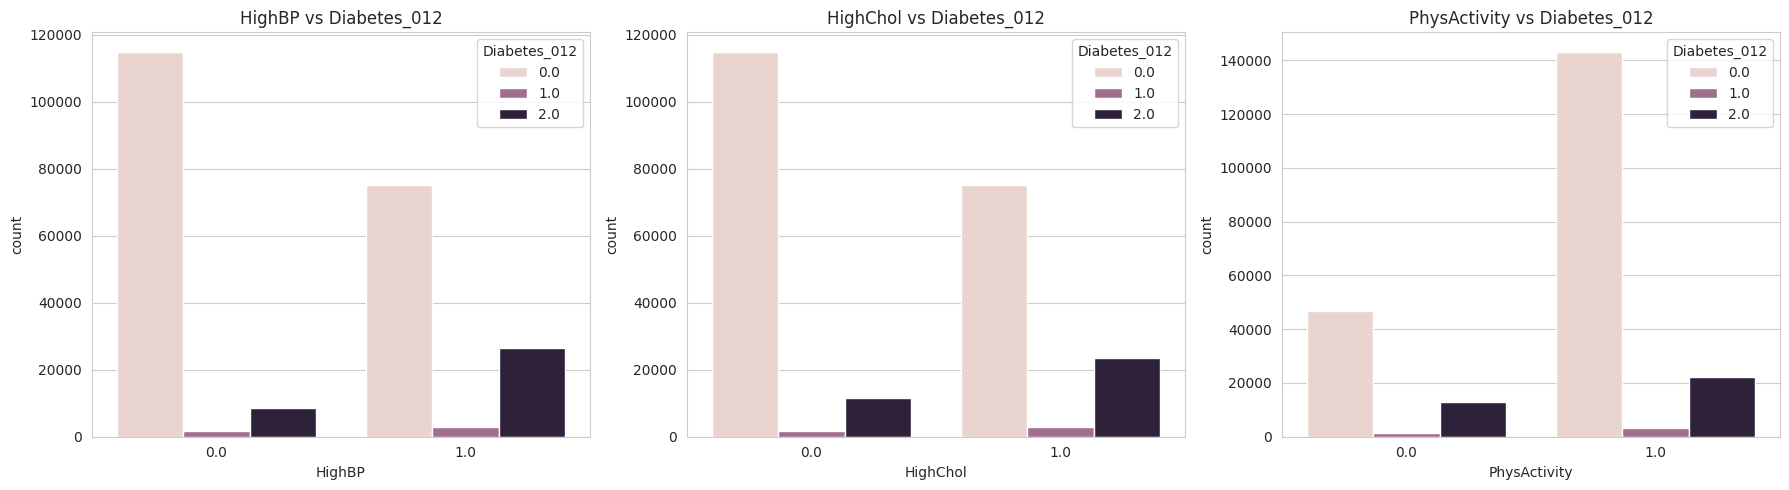

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='HighBP', hue=target, data=df, ax=axes[0])
axes[0].set_title("HighBP vs Diabetes_012")

sns.countplot(x='HighChol', hue=target, data=df, ax=axes[1])
axes[1].set_title("HighChol vs Diabetes_012")

sns.countplot(x='PhysActivity', hue=target, data=df, ax=axes[2])
axes[2].set_title("PhysActivity vs Diabetes_012")

plt.tight_layout()
plt.show()

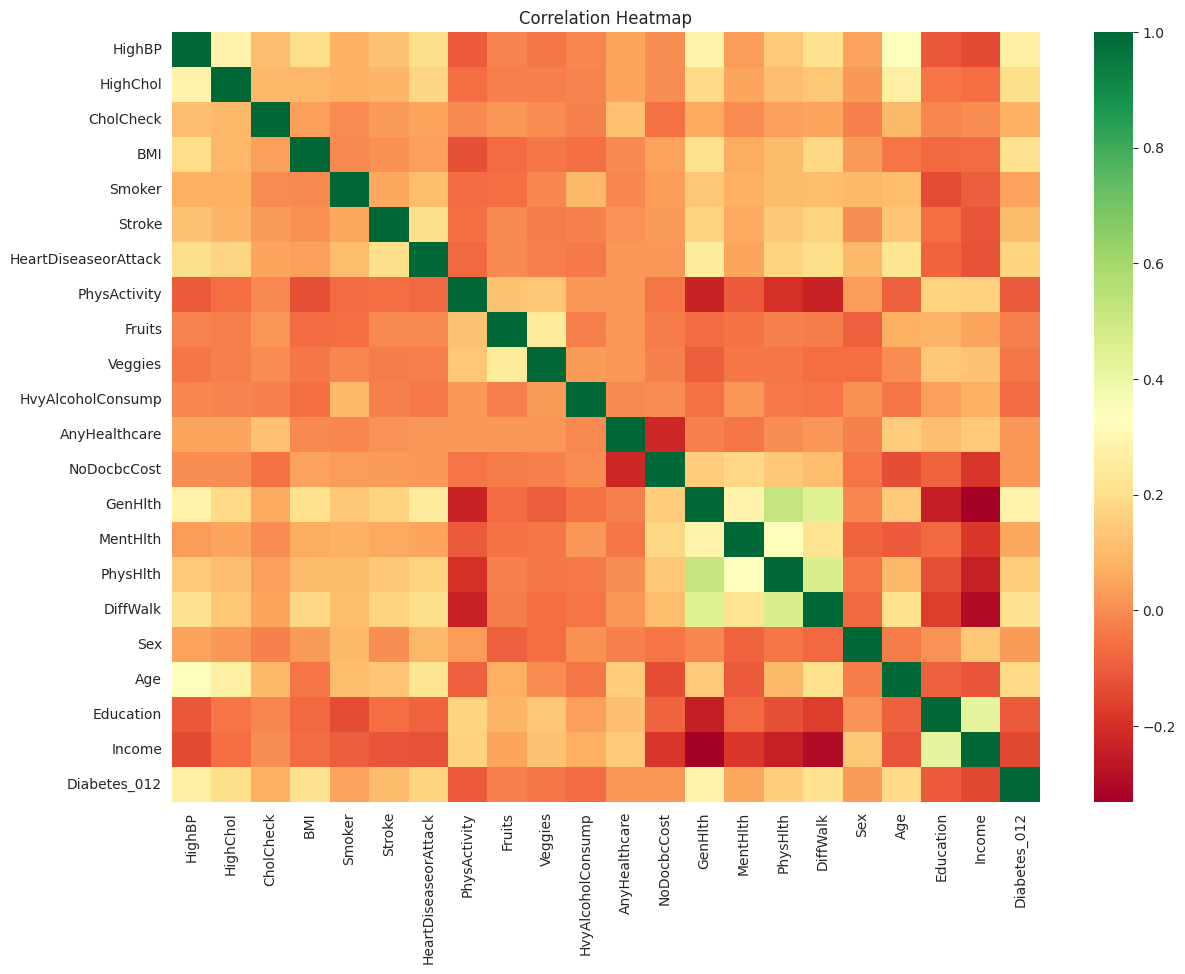

In [ ]:
plt.figure(figsize=(14,10))
corr_matrix = df[features + [target]].corr()
sns.heatmap(corr_matrix, cmap="RdYlGn", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif


k = 10

anova_selector = SelectKBest(score_func=f_classif, k=k)

X_train_selected = anova_selector.fit_transform(X_train_scaled, y_train)
X_test_selected = anova_selector.transform(X_test_scaled)

print("Shape after feature selection:", X_train_selected.shape)

Shape after feature selection: (183824, 10)


In [ ]:
selected_mask = anova_selector.get_support()
selected_features = X.columns[selected_mask]

print("Selected features using ANOVA:")
print(selected_features.tolist())

Selected features using ANOVA:
['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']


In [ ]:
anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": anova_selector.scores_,
    "p_value": anova_selector.pvalues_
})

anova_scores = anova_scores.sort_values(by="F_score", ascending=False)
anova_scores

,Feature,F_score,p_value
13,GenHlth,8025.253606,0.000000e+00
0,HighBP,6733.072646,0.000000e+00
3,BMI,4281.301019,0.000000e+00
16,DiffWalk,4172.367557,0.000000e+00
1,HighChol,3978.453829,0.000000e+00
18,Age,3261.244270,0.000000e+00
6,HeartDiseaseorAttack,2705.679316,0.000000e+00
15,PhysHlth,2393.516161,0.000000e+00
20,Income,1987.828372,0.000000e+00
19,Education,1034.983849,0.000000e+00


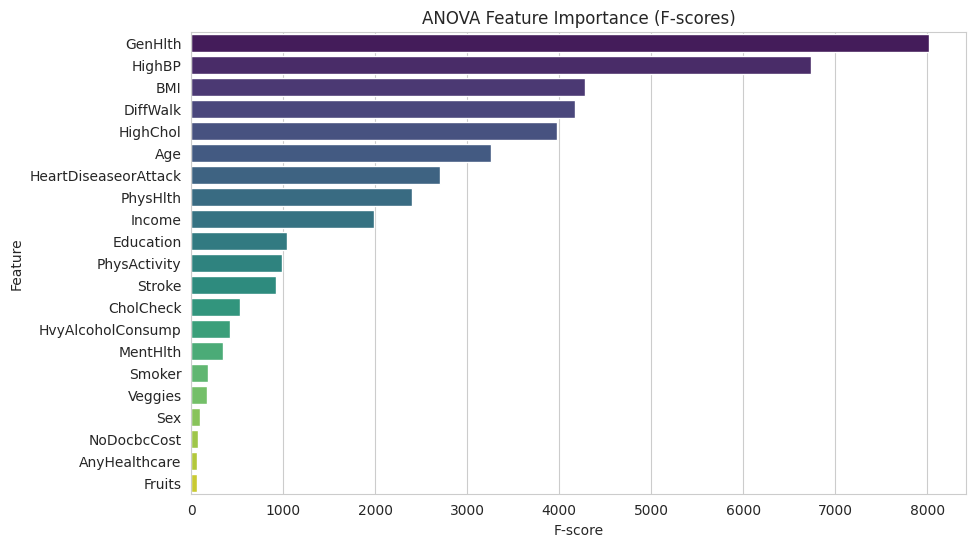

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=anova_scores, x="F_score", y="Feature", palette="viridis")
plt.title("ANOVA Feature Importance (F-scores)")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()

In [ ]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs",
    random_state=42
)

log_reg.fit(X_train_selected, y_train)
print("Model trained successfully.")

Model trained successfully.


In [ ]:
y_pred = log_reg.predict(X_test_selected)
y_prob = log_reg.predict_proba(X_test_selected)

print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_prob.shape)

Prediction shape: (45957,)
Probability shape: (45957, 3)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.6338751441564942
Precision: 0.8340471415627919
Recall   : 0.6338751441564942
F1-score : 0.7057339283384783
ROC-AUC  : 0.8018306528553042


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.65      0.77     38012
           1       0.03      0.28      0.06       926
           2       0.36      0.59      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.83      0.63      0.71     45957



In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Pred 0", "Pred 1", "Pred 2"]
)
cm_df

,Pred 0,Pred 1,Pred 2
Actual 0,24699,6405,6908
Actual 1,268,259,399
Actual 2,1295,1551,4173


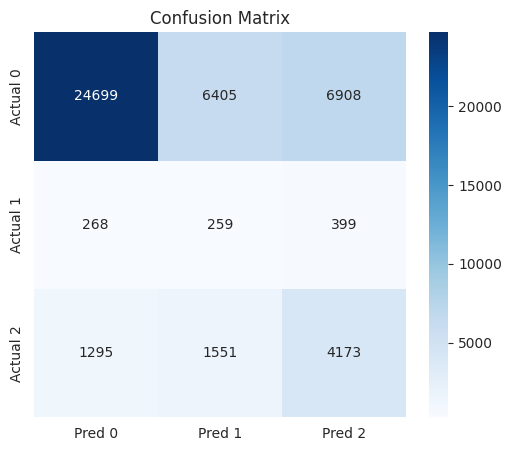

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

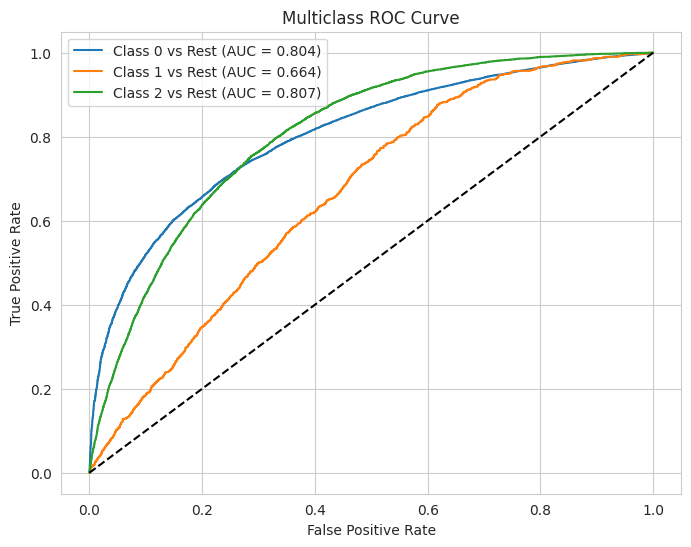

In [ ]:
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_cls = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} vs Rest (AUC = {roc_auc_cls:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [ ]:
coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=selected_features,
    columns=[f"Class_{cls}" for cls in log_reg.classes_]
)

coef_df

,Class_0,Class_1,Class_2
HighBP,-0.174906,-0.008275,0.183181
HighChol,-0.193499,0.086512,0.106987
BMI,-0.311359,0.096162,0.215197
HeartDiseaseorAttack,-0.027772,-0.034246,0.062018
GenHlth,-0.313848,0.023434,0.290414
PhysHlth,0.031347,0.000700,-0.032047
DiffWalk,-0.004158,-0.018482,0.022639
Age,-0.309424,0.101140,0.208284
Education,0.018493,-0.022018,0.003525
Income,0.078757,-0.068591,-0.010166


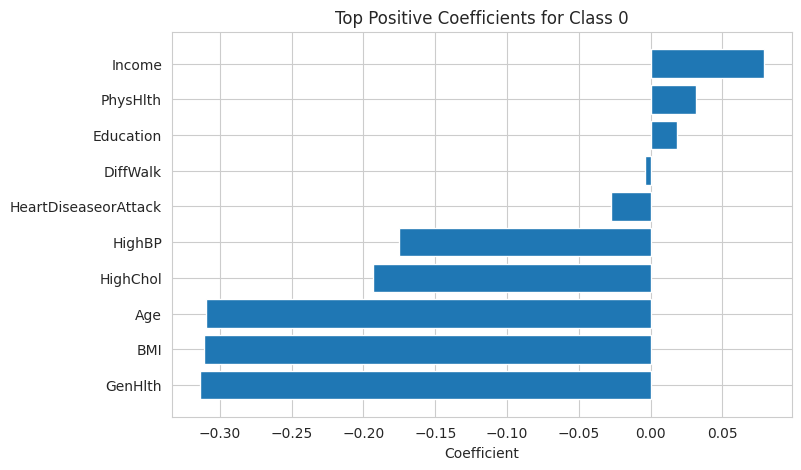

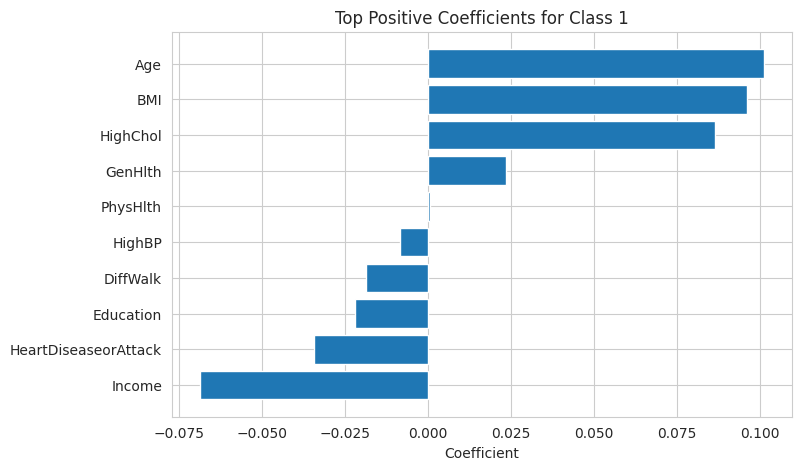

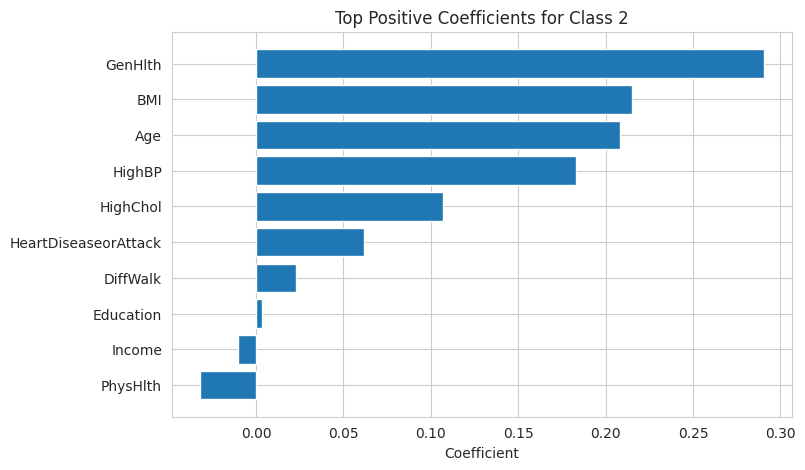

In [ ]:
for cls in log_reg.classes_:
    top_features = coef_df[f"Class_{cls}"].sort_values(ascending=False).head(10)

    plt.figure(figsize=(8,5))
    plt.barh(top_features.index, top_features.values)
    plt.gca().invert_yaxis()
    plt.title(f"Top Positive Coefficients for Class {cls}")
    plt.xlabel("Coefficient")
    plt.show()

**SHAP**

In [ ]:
import shap

sample_size = 1000
X_sample = X_test_selected[:sample_size]

print("Sample shape:", X_sample.shape)

Sample shape: (1000, 10)


In [ ]:
explainer = shap.Explainer(log_reg, X_train_selected)
shap_values = explainer(X_sample)

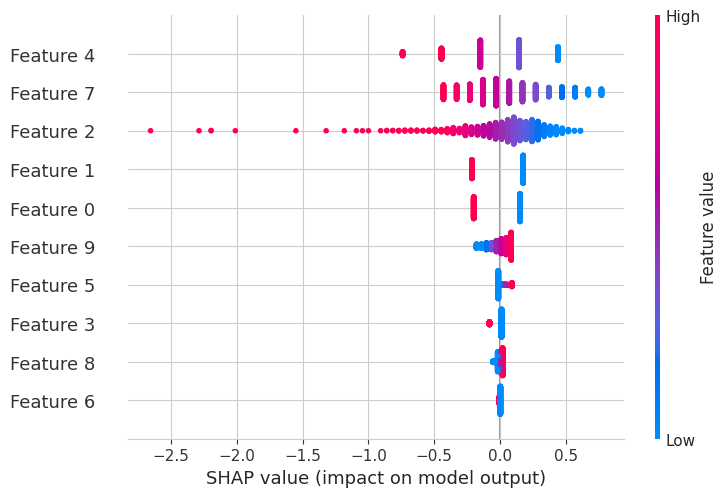

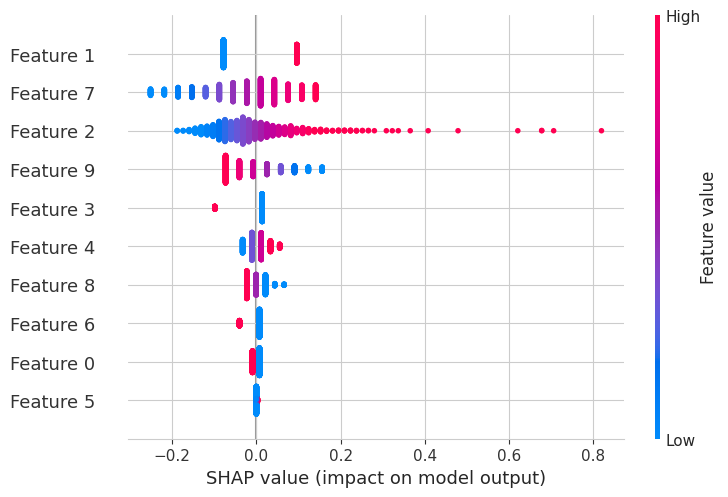

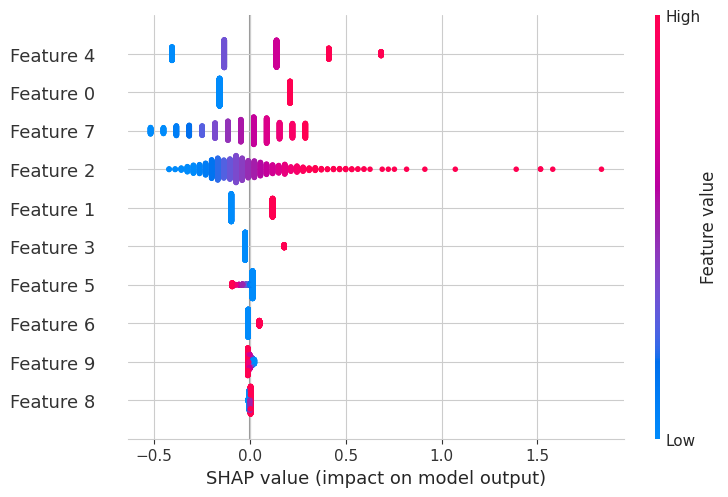

In [ ]:
shap.plots.beeswarm(shap_values[:,:,0])
shap.plots.beeswarm(shap_values[:,:,1])
shap.plots.beeswarm(shap_values[:,:,2])

In addition to coefficient-based interpretation, SHAP (SHapley Additive Explanations) was applied to provide a more detailed understanding of feature contributions.
The results show that features such as BMI, general health, and physical health have strong contributions toward predicting diabetes and prediabetes classes.

SHAP provides both global interpretability (overall feature importance) and local interpretability (individual predictions), making it a powerful tool for explaining model behavior.

**Checking Assumpations**

## Assumption 1 - Appropriate outcome type (Must be categorical)

Logistic Regression requires the dependent variable to be categorical.  
In this notebook, the target variable is `Diabetes_012`, which has three classes:
- 0 = No diabetes
- 1 = Prediabetes
- 2 = Diabetes

Therefore, multinomial logistic regression is appropriate.

## Assumption 2 - Linearity of independent variables and log odds

Logistic Regression assumes that continuous predictors have a linear relationship with the log odds of the outcome.

Since this is multinomial logistic regression, we perform an approximate check using a Box-Tidwell-style approach on selected continuous variables.

We will test the following continuous / ordinal variables:
- BMI
- MentHlth
- PhysHlth

In [ ]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit

In [ ]:
bt_df = X_train.copy()
bt_df["Diabetes_012"] = y_train.values

continuous_vars = ["BMI", "MentHlth", "PhysHlth"]

for col in continuous_vars:
    bt_df = bt_df[bt_df[col] > 0]

for col in continuous_vars:
    bt_df[f"{col}_log"] = bt_df[col] * np.log(bt_df[col])

bt_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_012,BMI_log,MentHlth_log,PhysHlth_log
49497,1.0,0.0,1.0,25.0,1.0,0.0,1.0,0.0,1.0,1.0,...,30.0,1.0,1.0,13.0,4.0,1.0,0,80.471896,102.035921,102.035921
54193,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,0.0,1.0,...,30.0,0.0,1.0,4.0,5.0,4.0,0,93.301726,0.000000,102.035921
195237,0.0,0.0,0.0,33.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,1.0,3.0,5.0,6.0,0,115.384750,102.035921,1.386294
178730,1.0,1.0,1.0,25.0,1.0,0.0,1.0,1.0,1.0,1.0,...,21.0,1.0,1.0,9.0,6.0,4.0,2,80.471896,102.035921,63.934971
5358,0.0,0.0,1.0,37.0,0.0,0.0,0.0,1.0,1.0,1.0,...,5.0,0.0,1.0,6.0,6.0,8.0,0,133.603963,3.295837,8.047190


In [ ]:
X_bt = bt_df[continuous_vars + [f"{col}_log" for col in continuous_vars]]
X_bt = sm.add_constant(X_bt)

y_bt = bt_df["Diabetes_012"]

bt_model = MNLogit(y_bt, X_bt).fit(method="newton", disp=False)
print(bt_model.summary())

                          MNLogit Regression Results                          
Dep. Variable:           Diabetes_012   No. Observations:                35126
Model:                        MNLogit   Df Residuals:                    35112
Method:                           MLE   Df Model:                           12
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                 0.08249
Time:                        01:45:38   Log-Likelihood:                -20119.
converged:                       True   LL-Null:                       -21927.
Covariance Type:            nonrobust   LLR p-value:                     0.000
Diabetes_012=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -10.3950      0.787    -13.214      0.000     -11.937      -8.853
BMI                0.6998      0.102      6.877      0.000       0.500       0.899
MentHlth          -0.0193      0.039

## Assumption 3 - No strongly influential outliers

Logistic Regression should not be overly affected by a small number of influential observations.

For large datasets, a practical way to inspect this is to:
- train the model
- compute predicted probabilities
- inspect extreme residual-like behavior

Because BRFSS is very large, we use a representative sample for this diagnostic.

In [ ]:
sample_size = 5000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_selected), size=sample_size, replace=False)

X_sample = X_train_selected[sample_idx]
y_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]

log_reg_sample = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs",
    random_state=42
)

log_reg_sample.fit(X_sample, y_sample)
y_sample_pred = log_reg_sample.predict(X_sample)
y_sample_prob = log_reg_sample.predict_proba(X_sample)

print("Sample model trained successfully.")

Sample model trained successfully.


In [ ]:
max_prob = y_sample_prob.max(axis=1)
misclassified = (y_sample_pred != y_sample)

outlier_df = pd.DataFrame({
    "Actual": y_sample,
    "Predicted": y_sample_pred,
    "Max_Prob": max_prob,
    "Misclassified": misclassified
})

potential_outliers = outlier_df[(outlier_df["Misclassified"] == True) & (outlier_df["Max_Prob"] > 0.90)]
uncertain_cases = outlier_df[outlier_df["Max_Prob"] < 0.40]

print("Potential influential / problematic cases:", len(potential_outliers))
print("Highly uncertain cases:", len(uncertain_cases))

Potential influential / problematic cases: 1
Highly uncertain cases: 592


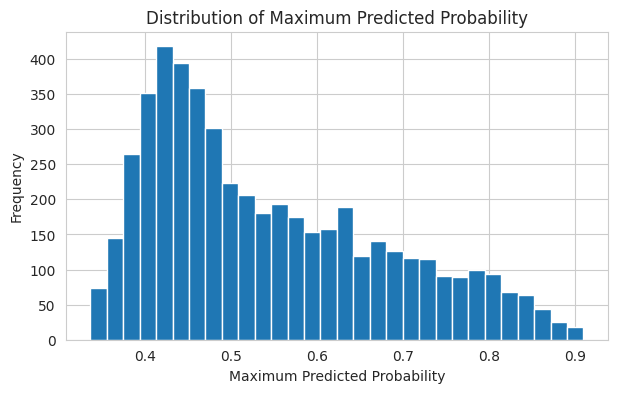

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(outlier_df["Max_Prob"], bins=30)
plt.title("Distribution of Maximum Predicted Probability")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Frequency")
plt.show()

**Inference:**

- Cases that are misclassified with very high confidence may indicate influential or unusual observations.
- If the proportion of such cases is small, the model is not heavily driven by a few extreme points.
- Because this is a very large dataset, the effect of a small number of unusual points is reduced.

## Assumption 4 - Absence of multicollinearity

Multicollinearity occurs when predictors are highly correlated with each other.

This can make coefficient estimates unstable and reduce interpretability.

We check this using Variance Inflation Factor (VIF).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
X_vif = X_train.copy()

X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
0,const,108.960313
14,GenHlth,1.716740
16,PhysHlth,1.592930
17,DiffWalk,1.510547
21,Income,1.430092
19,Age,1.351528
1,HighBP,1.302133
20,Education,1.272825
15,MentHlth,1.220312
7,HeartDiseaseorAttack,1.165439


**Inference:**

- A VIF value close to 1 indicates low multicollinearity.
- VIF values above 5 may indicate moderate multicollinearity.
- VIF values above 10 suggest serious multicollinearity.
- If high VIF values are found, those features should be reviewed or removed.

## Assumption 5 - Independence of observations

Logistic Regression assumes that observations are independent of each other.

This assumption is typically satisfied when:
- each row represents a different individual
- there are no repeated measurements of the same person
- there are no duplicate observations

In [ ]:
print("Duplicate rows in original dataset:", df.duplicated().sum())
print("Shape after duplicate removal:", df.shape)

Duplicate rows in original dataset: 0
Shape after duplicate removal: (229781, 22)


**Inference:**

- The BRFSS dataset represents survey responses from different individuals.
- Duplicate rows were checked and removed during preprocessing.
- Therefore, the independence of observations assumption is reasonably satisfied.

**Assumption 6**- Sufficiently large sample size

In [ ]:
class_counts = y.value_counts().sort_index()

print("Class counts:")
print(class_counts)

print("\nMinimum class count:", class_counts.min())
print("Total sample size:", len(y))

Class counts:
Diabetes_012
0    190055
1      4629
2     35097
Name: count, dtype: int64

Minimum class count: 4629
Total sample size: 229781


**Inference:**

- The dataset contains a very large number of observations.
- Each class has many samples, which supports stable coefficient estimation.
- Therefore, the sample size is sufficient for multinomial Logistic Regression.